# House Prices - Advanced Regression Techniques

*Predict sales prices and practice feature engineering, RFs, and gradient boosting*

# *Description & Evaluation*

**Goal**

It is your job to predict the sales price for each house. For each Id in the test set, you must predict the value of the SalePrice variable. 

**Practice Skills**

- Creative feature engineering 
- Advanced regression techniques like random forest and gradient boosting

**Metric**
  
Submissions are evaluated on Root-Mean-Squared-Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sales price. 
(Taking logs means that errors in predicting expensive houses and cheap houses will affect the result equally.)

**Acknowledgments**

The Ames Housing dataset was compiled by Dean De Cock for use in data science education. It's an incredible alternative for data scientists looking for a modernized and expanded version of the often cited Boston Housing dataset. 

# Import packages & dataset

In [1]:
# Import packages

# For data manipulation
import numpy as np
import pandas as pd
from datetime import date

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# For feature engineering
from scipy.stats import f_oneway
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

In [2]:
# Load data to dataframe train and test
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [3]:
# Display the first few row of the data
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Basic information about the data
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Overview columns

In [5]:
target = ['SalesPrice']

In [6]:
numeric = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'TotalBsmtSF', 'GrLivArea', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 
    'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 
    'Fireplaces', 'GarageCars', 'GarageArea', 
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', '3SsnPorch', 'PoolArea', 
    'MiscVal'
]               

In [7]:
categorical_nominal = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'Utilities', 'LotConfig',
    'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 
    'Foundation', 'Heating', 'Electrical', 'Functional', 'GarageType', 
    'PavedDrive', 'MiscFeature', 'SaleType', 'SaleCondition', 
]

In [8]:
categorical_ordinal = [
    'LotShape', 'LandContour','LandSlope', 
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 
    'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence']

In [9]:
boolean = ['CentralAir']

In [10]:
year = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

In [11]:
# drop column ID and MoSold 
train_df = train_df.drop(['Id', 'MoSold'], axis=1)

# Handle missing values

In [12]:
# summary missing value
missing = train_df.isnull().sum()
missing = missing[missing > 0]
missing_percentage = missing / len(train_df) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percentage
})

missing_table = missing_table.sort_values(by='Missing %', ascending=False)

missing_table

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [13]:
# Missing value in CATEGORICAL VARIABLES in this dataset do not mean "real" missing data

# PoolQC, MiscFeature, Alley, Fence, FireplaceQu --> No Pool, no Alley, ...
# GarageType, GarageFinish, GarageQual, GarageCond, (all missing 81 values) --> No Garage
# BsmtFinType2, BsmtExposure, BsmtCond, BsmtFinType1, BsmtQual (all missing 37 values) --> No basement

# --> Fill missing values as "None"

fill_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtFinType1', 'BsmtQual']
for col in fill_cols:
    train_df[col] = train_df[col].fillna("None")

In [14]:
# Drop the only one row with missing value in Electrical
train_df = train_df.dropna(subset=['Electrical'])
train_df.shape

(1459, 79)

In [15]:
# Missing values in NUMERIC VARIABLES

# Check if there are any row with MasVnrType but do not contain MasVnrAre value
mask = train_df['MasVnrType'].notnull() & train_df['MasVnrArea'].isnull()
train_df[mask][['MasVnrType', 'MasVnrArea']]

,MasVnrType,MasVnrArea


In [16]:
# Check MasVnrArea --> confirm that missing values only appear in houses which do not have MasVnrType
train_df[train_df['MasVnrArea'].isnull()]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,YrSold,SaleType,SaleCondition,SalePrice
234,60,RL,NaN,7851,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,625,Unf,0,235,860,GasA,Ex,Y,SBrkr,860,1100,0,1960,1,0,2,1,4,1,Gd,8,Typ,2,TA,BuiltIn,2002.0,Fin,2,440,TA,TA,Y,288,48,0,0,0,0,None,None,None,0,2010,WD,Normal,216500
529,20,RL,NaN,32668,Pave,None,IR1,Lvl,AllPub,CulDSac,Gtl,Crawfor,Norm,Norm,1Fam,1Story,6,3,1957,1975,Hip,CompShg,Wd Sdng,Stone,NaN,NaN,Gd,TA,PConc,TA,TA,No,Rec,1219,Unf,0,816,2035,GasA,TA,Y,SBrkr,2515,0,0,2515,1,0,3,0,4,2,TA,9,Maj1,2,TA,Attchd,1975.0,RFn,2,484,TA,TA,Y,0,0,200,0,0,0,None,None,None,0,2007,WD,Alloca,200624
650,60,FV,65.0,8125,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,2Story,7,6,2007,2007,Gable,CompShg,CemntBd,CmentBd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,813,813,GasA,Ex,Y,SBrkr,822,843,0,1665,0,0,2,1,3,1,Gd,7,Typ,0,None,Attchd,2007.0,RFn,2,562,TA,TA,Y,0,0,0,0,0,0,None,None,None,0,2008,WD,Normal,205950
936,20,RL,67.0,10083,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,SawyerW,Norm,Norm,1Fam,1Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,833,Unf,0,343,1176,GasA,Ex,Y,SBrkr,1200,0,0,1200,1,0,2,0,2,1,Gd,5,Typ,0,None,Attchd,2003.0,RFn,2,555,TA,TA,Y,0,41,0,0,0,0,None,None,None,0,2009,WD,Normal,184900
973,20,FV,95.0,11639,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,Somerst,Norm,Norm,1Fam,1Story,7,5,2007,2008,Gable,CompShg,CemntBd,CmentBd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,1428,1428,GasA,Ex,Y,SBrkr,1428,0,0,1428,0,0,2,0,3,1,Gd,6,Typ,0,None,Attchd,2007.0,Fin,2,480,TA,TA,Y,0,120,0,0,0,0,None,None,None,0,2008,New,Partial,182000
977,120,FV,35.0,4274,Pave,Pave,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,TwnhsE,1Story,7,5,2006,2007,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,1106,Unf,0,135,1241,GasA,Ex,Y,SBrkr,1241,0,0,1241,1,0,1,1,1,1,Gd,4,Typ,0,None,Attchd,2007.0,Fin,2,569,TA,TA,Y,0,116,0,0,0,0,None,None,None,0,2007,New,Partial,199900
1243,20,RL,107.0,13891,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,Norm,Norm,1Fam,1Story,10,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Ex,TA,PConc,Ex,Gd,Gd,GLQ,1386,Unf,0,690,2076,GasA,Ex,Y,SBrkr,2076,0,0,2076,1,0,2,1,2,1,Ex,7,Typ,1,Gd,Attchd,2006.0,Fin,3,850,TA,TA,Y,216,229,0,0,0,0,None,None,None,0,2006,New,Partial,465000
1278,60,RL,75.0,9473,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,8,5,2002,2002,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,804,Unf,0,324,1128,GasA,Ex,Y,SBrkr,1128,903,0,2031,1,0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,2002.0,RFn,2,577,TA,TA,Y,0,211,0,0,0,0,None,None,None,0,2008,WD,Normal,237000


In [17]:
# Fill missing values in MasVnrArea = 0 and MasVnrType = None
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)
train_df['MasVnrType'] = train_df['MasVnrType'].fillna("None")

In [18]:
# Fill missing values in GarageYrBlt = 0 (as those houses do not have a garage)
train_df['GarageYrBlt'] = train_df['GarageYrBlt'].fillna(0)

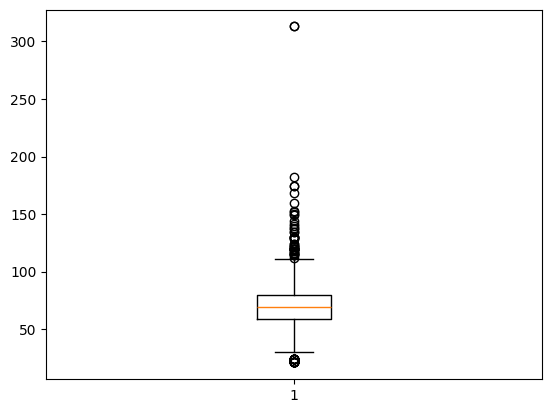

In [19]:
# Check if LotFrontage has outliers to decide fill method
plt.boxplot(train_df['LotFrontage'].dropna())
plt.show()

In [20]:
# As there are many outliers in LotFrontage --> fill missing values with median
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df['LotFrontage'].median())

In [21]:
# Check after handling missing values
check_missing = train_df.isnull().sum()
check_missing = check_missing[check_missing > 0]
check_missing

Series([], dtype: int64)

# Feature engineering

## Target variable - y: SalePrice

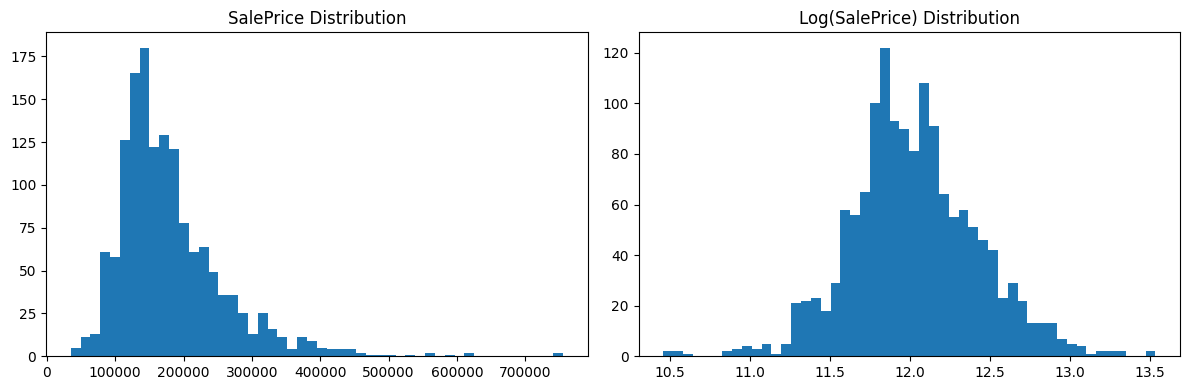

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of SalePrice
axs[0].hist(train_df['SalePrice'], bins=50)
axs[0].set_title('SalePrice Distribution')

# Distribution of Log(SalePrice)
axs[1].hist(np.log1p(train_df['SalePrice']), bins=50)
axs[1].set_title('Log(SalePrice) Distribution')

plt.tight_layout()
plt.show()

In [23]:
# Nhận xét:
# Target Y - SalePrice phân phối gần chuẩn, lệch phải --> Sau khi log thì ít lệch phải hơn

## Predictor variables - X

In [24]:
# Create HouseAge, YearsSinceRemodel', 'YearsSinceGarage', 'YearsSinceSold'

# calculate
train_df['HouseAge'] = train_df['YrSold'] - train_df['YearBuilt']
train_df['YearsSinceRemodel'] = train_df['YrSold'] - train_df['YearRemodAdd']
train_df['YearsSinceGarage'] = train_df['YrSold'] - train_df['GarageYrBlt']
train_df['YearsSinceSold'] = train_df['YrSold'].max() - train_df['YrSold']

# append new columns to numeric list
numeric.append('HouseAge')
numeric.append('YearsSinceRemodel')
numeric.append('YearsSinceGarage')
numeric.append('YearsSinceSold')

# drop year columns
train_df = train_df.drop(['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt'], axis=1)

In [25]:
# Create TotalSF
train_df['TotalSF'] = train_df['GrLivArea'] + train_df['TotalBsmtSF']
numeric.append('TotalSF')

In [26]:
# Cretae TotalBath
train_df['TotalBath'] = (train_df['BsmtFullBath'] + 
                         train_df['FullBath'] + 
                         0.5 * (train_df['BsmtHalfBath'] + train_df['HalfBath']))
numeric.append('TotalBath')

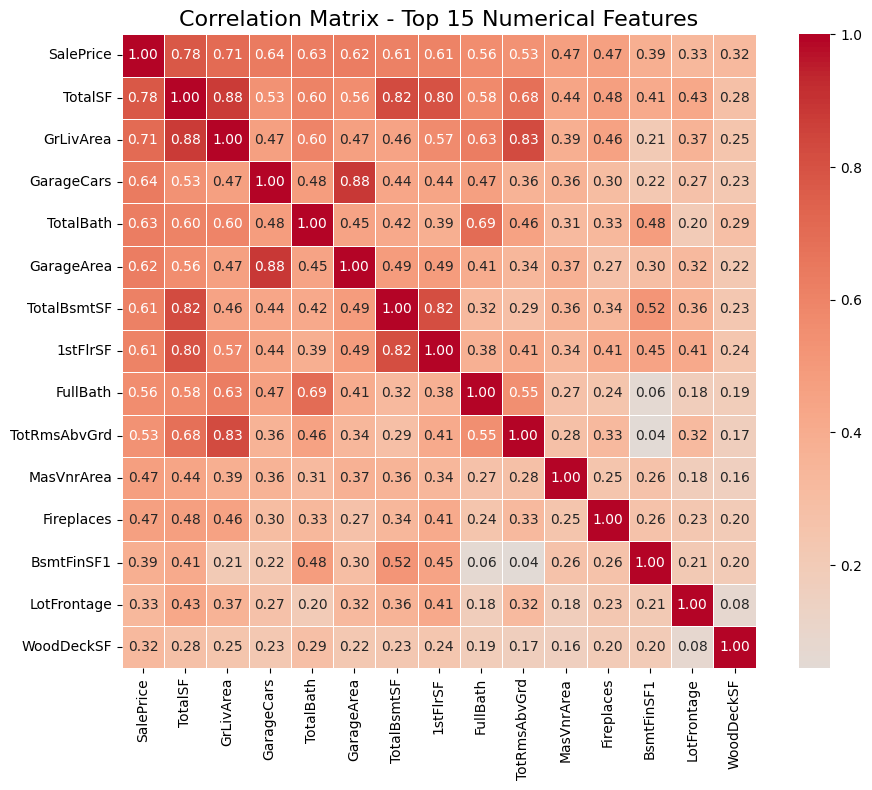

In [27]:
# Calculate correlation with SalePrice
corr_with_target = train_df[numeric + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)

# Heatmap for top 15 highest correlation
top_numeric = corr_with_target.head(15).index
corr_matrix = train_df[top_numeric].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Top 15 Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

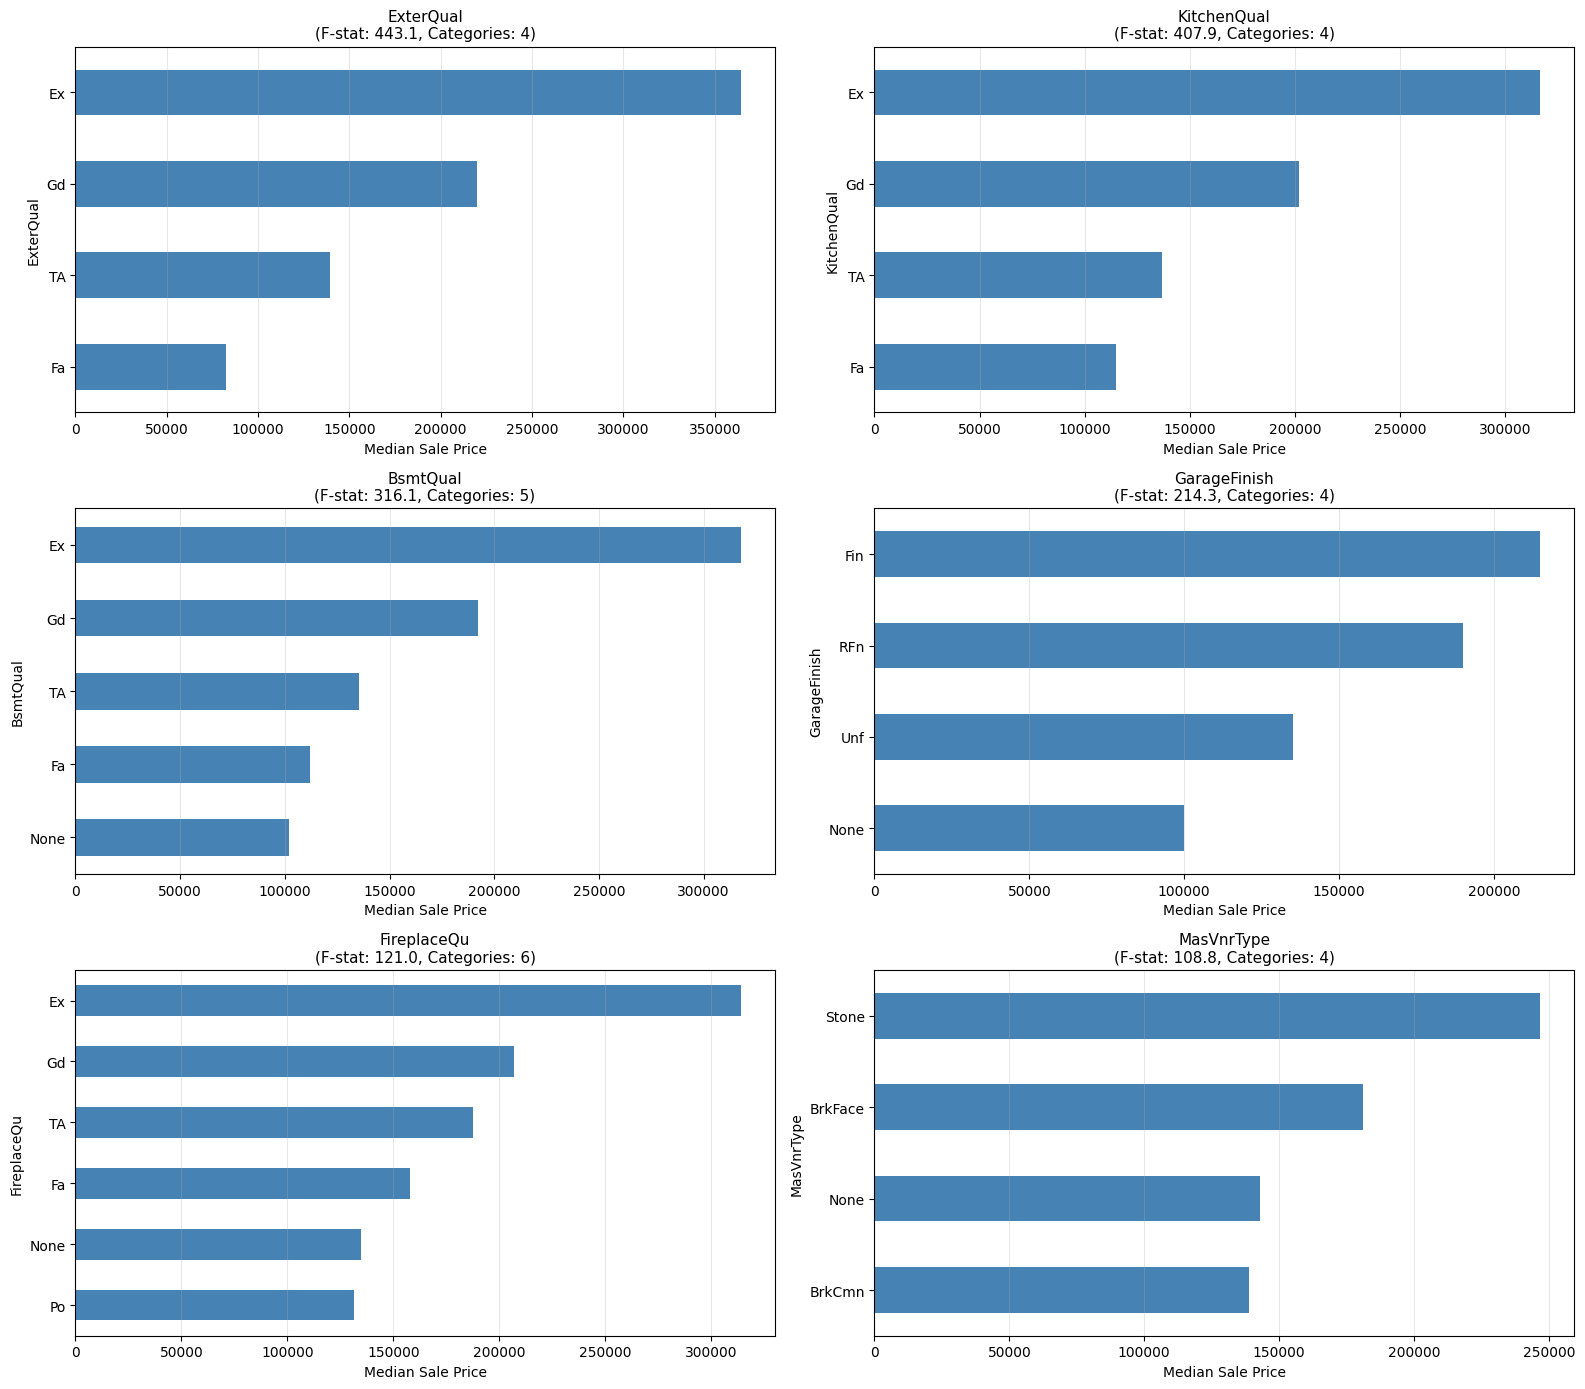

In [28]:
# ANOVA F-statistic for categorical x
all_categorical = categorical_nominal + categorical_ordinal + boolean

f_stats = {}
for col in all_categorical:
    try:
        groups = train_df.dropna(subset=[col, 'SalePrice']).groupby(col)['SalePrice'].apply(list)
        if len(groups) > 1:
            f_stat, p_value = f_oneway(*groups)
            f_stats[col] = {
                'F-statistic': f_stat, 
                'p-value': p_value,
                'n_categories': train_df[col].nunique()
            }
    except:
        pass

f_stats_df = pd.DataFrame(f_stats).T.sort_values('F-statistic', ascending=False)

top_cats = f_stats_df.head(6).index

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(top_cats):
    median_price = train_df.groupby(col)['SalePrice'].median().sort_values()
    median_price.plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col}\n(F-stat: {f_stats_df.loc[col, "F-statistic"]:.1f}, Categories: {f_stats_df.loc[col, "n_categories"]:.0f})', 
                     fontsize=11)
    axes[i].set_xlabel('Median Sale Price')
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Create function to draw chart for CONTINUOUS NUMERIC VARIABLES

def hist_and_scatter(df, col, target):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    axs[0].hist(df[col], bins=30)
    axs[0].set_title(f'{col} Distribution')

    # Scatter
    axs[1].scatter(df[col], df[target], alpha=0.5)
    axs[1].set_title(f'{col} vs {target}')

    # Calculate correlation score
    corr_score = df[col].corr(df[target])
    print(f'{col} vs {target} correlation score: {corr_score}')

    plt.tight_layout()
    plt.show()

In [30]:
# Create function to draw chart for DISCRETE NUMERIC VARIABLES
def hist_and_boxplot(df, col, target):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    axs[0].hist(df[col], bins=30)
    axs[0].set_title(f'{col} Distribution')
    
    # Boxplot instead of scatter
    df.boxplot(column=target, by=col, ax=axs[1])
    axs[1].set_title(f'{col} vs {target}')
    axs[1].set_xlabel(col)
    axs[1].set_ylabel(target)
    plt.suptitle('')  # Remove default title from boxplot
    
    # Calculate correlation score
    corr_score = df[col].corr(df[target])
    print(f'{col} vs {target} correlation score: {corr_score}')
    plt.tight_layout()
    plt.show()

In [31]:
# Create function to draw chart for CATEGORICAL VARIABLES
def bar_chart(df, col, target):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution
    df[col].value_counts().plot(kind='bar', ax=axs[0])
    axs[0].set_title(f'{col} Distribution')
    axs[0].set_xlabel(col)
    axs[0].set_ylabel('Count')
    
    # Median Price by category
    df.groupby(col)[target].median().sort_values().plot(kind='barh', ax=axs[1])
    axs[1].set_title(f'Median {target} by {col}')
    axs[1].set_xlabel(f'Median {target}')
    axs[1].set_ylabel(col)
    
    plt.tight_layout()
    plt.show()

### HouseAge

HouseAge vs SalePrice correlation score: -0.5237221913662243


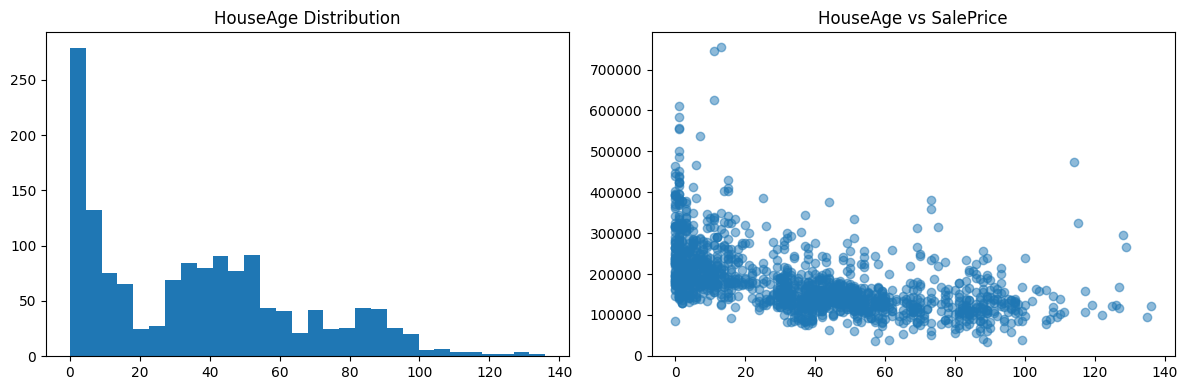

In [32]:
# HouseAge
hist_and_scatter(train_df, 'HouseAge', 'SalePrice')

In [33]:
# Nhận xét
# Biều đồ 1:
# Phân phối rất lệch phải (nhiều nhà mới được bán hơn nhà cũ), đa số nhà được bán trong khoảng 0-10 năm tuổi
# Có cả nhà hơn 100 năm tuổi, nhưng ít
# Biểu đồ 2:
# Nhà mới thì giá phân tán hơn, có cả giá rất cao (có thể là outlier)
# Nhà cũ thì giá tập trung ở đoạn thấp hơn
# Có cả nhà cũ nhưng giá vẫn cao (ít)


<Axes: title={'center': 'SalePrice'}, xlabel='HouseAgeBin'>

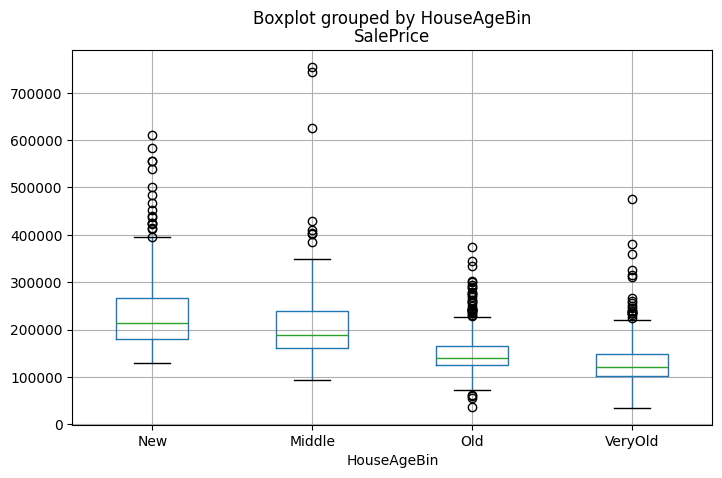

In [34]:
# Bin HouseAge
train_df["HouseAgeBin"] = pd.cut(
    train_df["HouseAge"],
    bins=[0, 10, 30, 60, 120],
    labels=["New", "Middle", "Old", "VeryOld"]
)
train_df.boxplot(column="SalePrice", by="HouseAgeBin", figsize=(8,5))

In [35]:
# Nhận xét:
# Giá nhà giảm dần theo tuổi (New → VeryOld) (median - nhìn đường xanh lá)
# NNhà cũ có phân bố giá ổn định hơn (IQR - chiều rộng của cái hộp)
# Có nhiều outliers

### YearsSinceRemodel

YearsSinceRemodel vs SalePrice correlation score: -0.5094045425904251


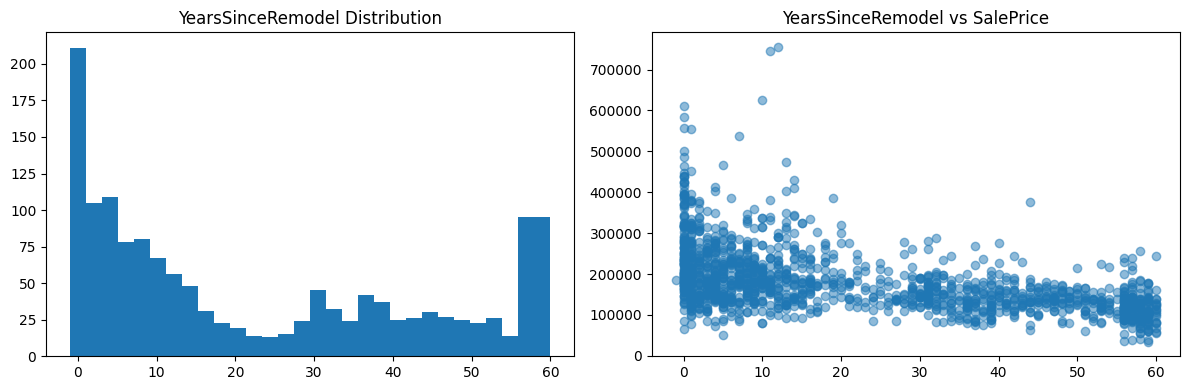

In [36]:
hist_and_scatter(train_df, 'YearsSinceRemodel', 'SalePrice')

In [37]:
# Biều đồ 1:
# Nhóm nhà mới sửa chiếm đa số
# Nhóm 60 năm --> Nhà chưa từng được sửa, năm xây = năm sửa

# Biều đồ 2:
# Nhà mới sửa: giá cao hơn + phân tán hơn
# Nhà càng lâu không sửa thì giá càng thấp và ổn định hơn

### TotalSF

TotalSF vs SalePrice correlation score: 0.7791035403797558


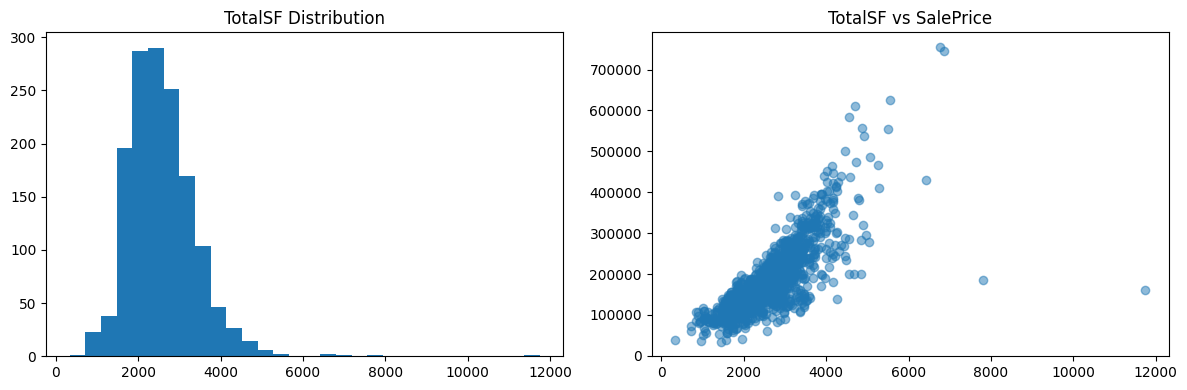

In [38]:
hist_and_scatter(train_df, 'TotalSF', 'SalePrice')

In [39]:
# Nhận xét:
# Biểu đồ 1:
# Phân phối chuẩn, hơi lệch phải
# Phần lớn nhà có diện tích sử dụng trong khoảng 2000 - 4000
# Có 1 số nhỏ 12000 --> Check xem có phải outlier không

# Biểu đồ 2:
# Nhà có diện tích sống lớn thì giá cao hơn
# Nhà có diện tích rất to 8000, 12000 lại có giá thấp

### LotFrontage

GarageArea vs SalePrice correlation score: 0.6234228990077114


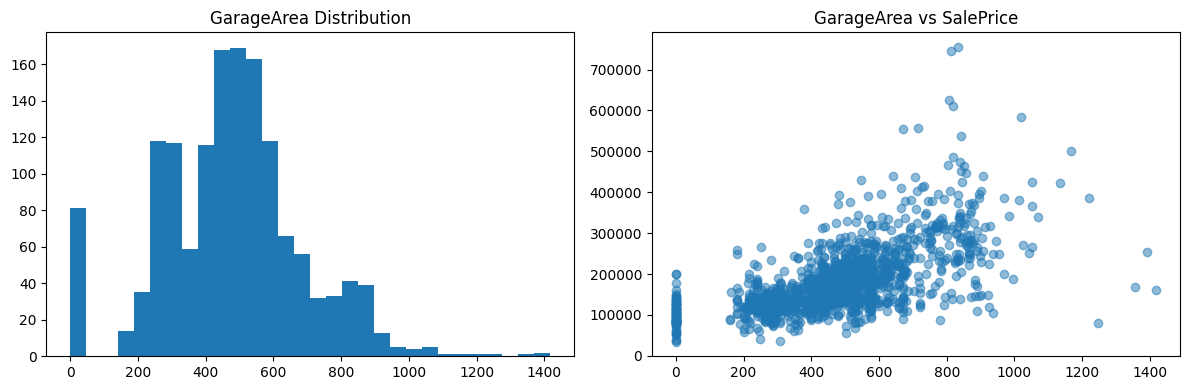

In [40]:
hist_and_scatter(train_df, 'GarageArea', 'SalePrice')

In [41]:
# Nhận xét
# Biểu đồ 1:
# Có 2 nhóm: nhà không có garage và có garage
# Phân phối gần chuẩn

# Biều đồ 2:
# Nhà không có garage thì giá thấp hơn
# GarageArea tăng thì giá tăng

### TotalBath

TotalBath vs SalePrice correlation score: 0.6318093609860971


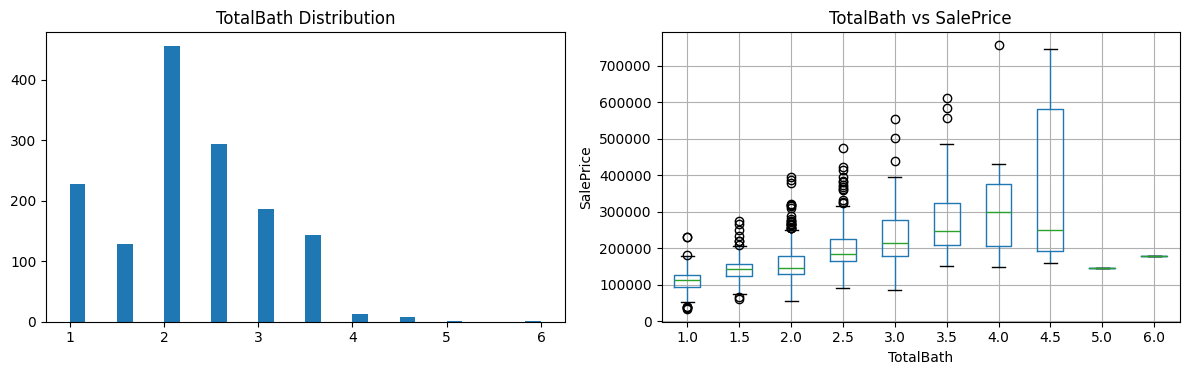

In [42]:
hist_and_boxplot(train_df, 'TotalBath', 'SalePrice')

In [43]:
# Nhận xét:
# Biểu đồ 1:
# Nhiều nhà có 2 bồn tắm

# Biểu đồ 2:
# Nhà có nhiều bốn tắm thì giá cao dần (nhà có 4.5 bồn tắm trở lên thì giá lại thấp)
# Giá nhà có nhiều bồn tắm thì phân tán hơn (nhà 5, 6 bốn tắm thì có rất ít)

### Neighborhood

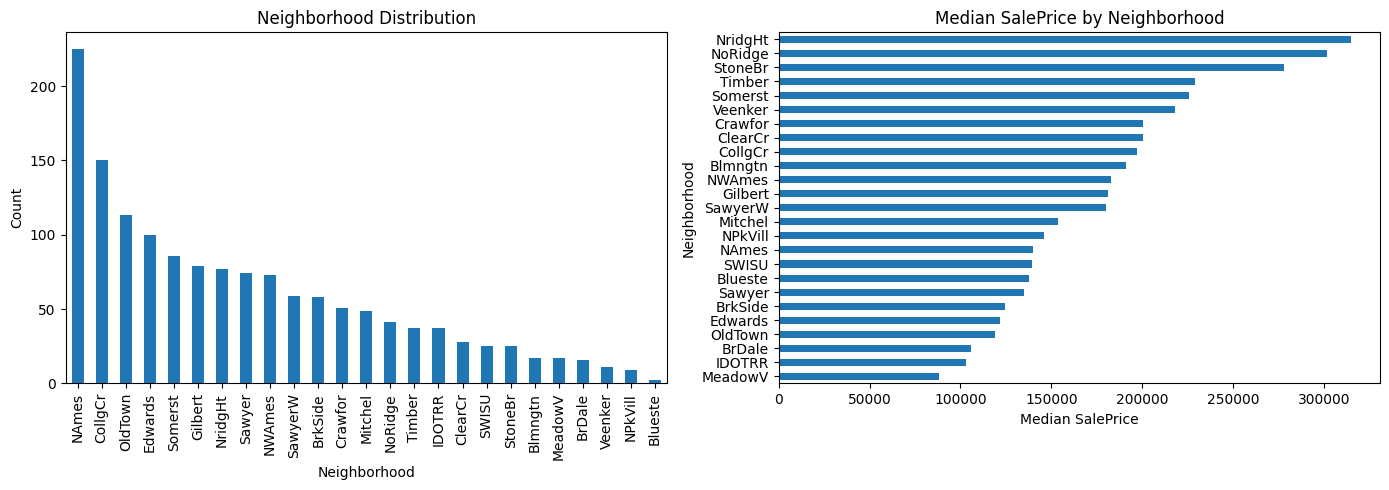

In [44]:
bar_chart(train_df, 'Neighborhood', 'SalePrice')

In [45]:
# Nhận xét
# Nhiều nhà ở vùng NAmes
# Nhà ở NridgHt giá cao

# Encoding

### OneHotEncoder for Nominal Categorical X

In [46]:
# OneHotEncoder for nominal categorical variables
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe.fit(train_df[categorical_nominal])

ohe_transformed = ohe.transform(train_df[categorical_nominal])

In [47]:
# Check result
ohe_df = pd.DataFrame(
    ohe_transformed,
    columns=ohe.get_feature_names_out(categorical_nominal)
)

ohe_df.head()

,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_None,Alley_Pave,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,PavedDrive_N,PavedDrive_P,PavedDrive_Y,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,

### OrdinalEncoder for Ordinal Categorical X

In [48]:
# Define ordinal mapping
ordinal_mapping = {
    "ExterQual":      ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond":      ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual":       ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond":       ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure":   ["None", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1":   ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC":      ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual":    ["Po", "Fa", "TA", "Gd", "Ex"],
    "FireplaceQu":    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish":   ["None", "Unf", "RFn", "Fin"],
    "GarageQual":     ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond":     ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "PoolQC":         ["None", "Fa", "TA", "Gd", "Ex"],
    "Fence":          ["None", "MnWw", "GdWo", "MnPrv", "GdPrv"]
}

In [49]:
# Ordinal Encoder
ordinal_cols = list(ordinal_mapping.keys())
categories = list(ordinal_mapping.values())

oe = OrdinalEncoder(categories=categories)
oe.fit(train_df[ordinal_cols])

ordinal_transformed = oe.transform(train_df[ordinal_cols])

In [50]:
# Check result
ordinal_df = pd.DataFrame(
    ordinal_transformed,
    columns=ordinal_cols
)

ordinal_df.head()

,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,HeatingQC,KitchenQual,FireplaceQu,GarageFinish,GarageQual,GarageCond,PoolQC,Fence
0,3.0,2.0,4.0,3.0,1.0,6.0,4.0,3.0,0.0,2.0,3.0,3.0,0.0,0.0
1,2.0,2.0,4.0,3.0,4.0,5.0,4.0,2.0,3.0,2.0,3.0,3.0,0.0,0.0
2,3.0,2.0,4.0,3.0,2.0,6.0,4.0,3.0,3.0,2.0,3.0,3.0,0.0,0.0
3,2.0,2.0,3.0,4.0,1.0,5.0,3.0,3.0,4.0,1.0,3.0,3.0,0.0,0.0
4,3.0,2.0,4.0,3.0,3.0,6.0,4.0,3.0,3.0,2.0,3.0,3.0,0.0,0.0


### For Boolean X

In [51]:
train_df["CentralAir"] = train_df["CentralAir"].map({"Y": 1, "N": 0})

# Final df

In [52]:
# Check all cols after encoding
df_encoded = pd.concat([
    train_df.drop(columns=categorical_nominal + categorical_ordinal),
    ohe_df,
    ordinal_df
], axis=1)

df_encoded.head()

,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,SalePrice,HouseAge,YearsSinceRemodel,YearsSinceGarage,YearsSinceSold,TotalSF,TotalBath,HouseAgeBin,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,Alley_Grvl,Alley_None,Alley_Pave,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,PavedDrive_N,PavedDrive_P,PavedDrive_Y,MiscFeature_Gar2,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,HeatingQC,KitchenQual,FireplaceQu,GarageFinish,GarageQual,GarageCond,PoolQC,Fence
0,65.0,8450.0,7.0,5.0,196.0,706.0,Unf,0.0,150.0,856.0,1.0,856.0,854.0,0.0,1710.0,1.0,0.0,2.0,1.0,3.0,1.0,8.0,0.0,2.0,548.0,0.0,61.0,0.0,0.0,0.0,0.0,0.0,2